[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-jwst-image-ring-nebula/notebook.ipynb)

# A real JWST view of the Ring Nebula, a nearby planetary nebula

The Ring Nebula is a 'planetary nebula' -- a glowing shell of gas blown off by a dying, sun-like star (nothing to do with actual planets; the name is a historical accident from how these looked in old, low-resolution telescopes). JWST imaged it in stunning detail, and I wanted to pull real NIRCam observations of it straight from the MAST archive myself.

In [1]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord

coord = SkyCoord.from_name('Ring Nebula')
obs = Observations.query_criteria(coordinates=coord, radius='0.03 deg',
                                   obs_collection='JWST', instrument_name='NIRCAM/IMAGE')
print(len(obs), 'JWST NIRCam imaging observations found near the Ring Nebula')

4 JWST NIRCam imaging observations found near the Ring Nebula


In [2]:
products = Observations.get_product_list(obs[0])
previews = Observations.filter_products(products, productType='PREVIEW', extension='jpg')
i2d_rows = [row for row in previews if 'i2d' in row['productFilename']]
target_row = i2d_rows[0] if i2d_rows else previews[0]
print(target_row['productFilename'])
manifest = Observations.download_products(target_row, mrp_only=False)
print(manifest)

jw01558005001_04101_00001_nrcb2_i2d.jpg


 [Done]


                                         Local Path                                         ...
------------------------------------------------------------------------------------------- ...
.\mastDownload\JWST\jw01558005001_04101_00001_nrcb2\jw01558005001_04101_00001_nrcb2_i2d.jpg ...


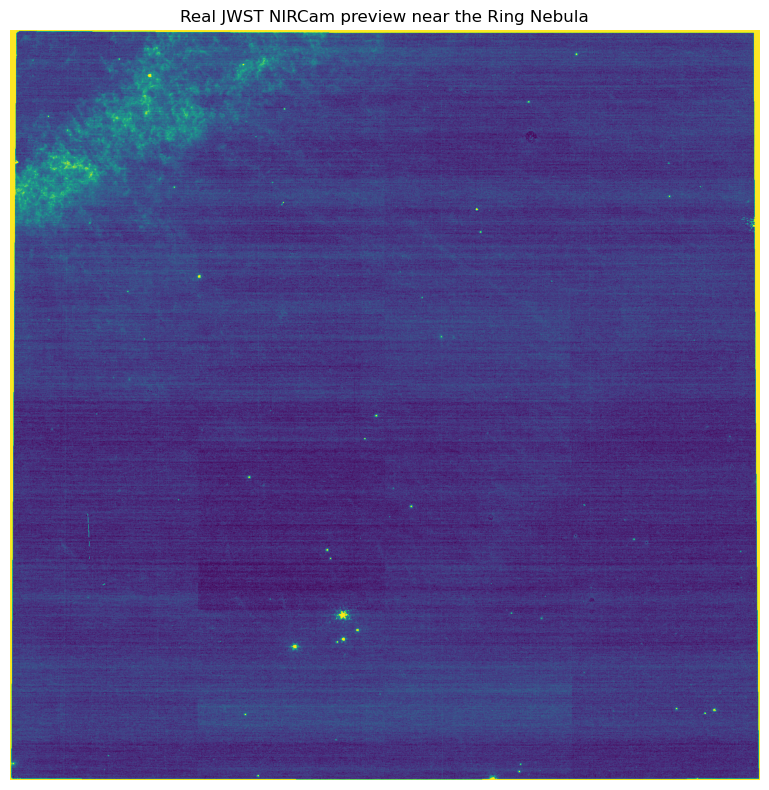

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil

local_path = manifest['Local Path'][0]
shutil.copy(local_path, 'ring_nebula.jpg')
img = mpimg.imread('ring_nebula.jpg')
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title('Real JWST NIRCam preview near the Ring Nebula')
plt.tight_layout()
plt.savefig('ring_display.png', dpi=120)
plt.show()

This shell was ejected only a few thousand years ago in astronomical terms, and it's still visibly expanding -- what makes JWST's infrared view special compared to earlier Hubble images is its sensitivity to the cooler, more diffuse gas and dust further out from the bright central ring, which shows up better at infrared wavelengths than in visible light.

**What I'd look at next:** Compare this NIRCam (near-infrared) preview against a MIRI (mid-infrared) observation of the same nebula, since the two instruments highlight quite different structures in the surrounding gas.

**Citation:** These observations were obtained with the NASA/ESA/CSA James Webb Space Telescope from the Mikulski Archive for Space Telescopes (MAST) at STScI. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.